TEXT ANALYSIS - CLEANED DATA

1. TEXT LENGTH STATISTICS (After Cleaning)
------------------------------------------------------------

full_text_cleaned:
count    100000.000000
mean         59.726620
std          77.894483
min           0.000000
25%          19.000000
50%          37.000000
75%          72.000000
max        3336.000000
Name: full_text_cleaned_length, dtype: float64

title_cleaned:
count    100000.00000
mean          5.73785
std           9.59052
min           0.00000
25%           0.00000
50%           3.00000
75%           9.00000
max         299.00000
Name: title_cleaned_length, dtype: float64

body_cleaned:
count    100000.000000
mean         49.581160
std          70.007289
min           0.000000
25%          15.000000
50%          29.000000
75%          58.000000
max        3315.000000
Name: body_cleaned_length, dtype: float64

2. WORD COUNT DISTRIBUTION
------------------------------------------------------------
count    100000.000000
mean         12.649910
std 

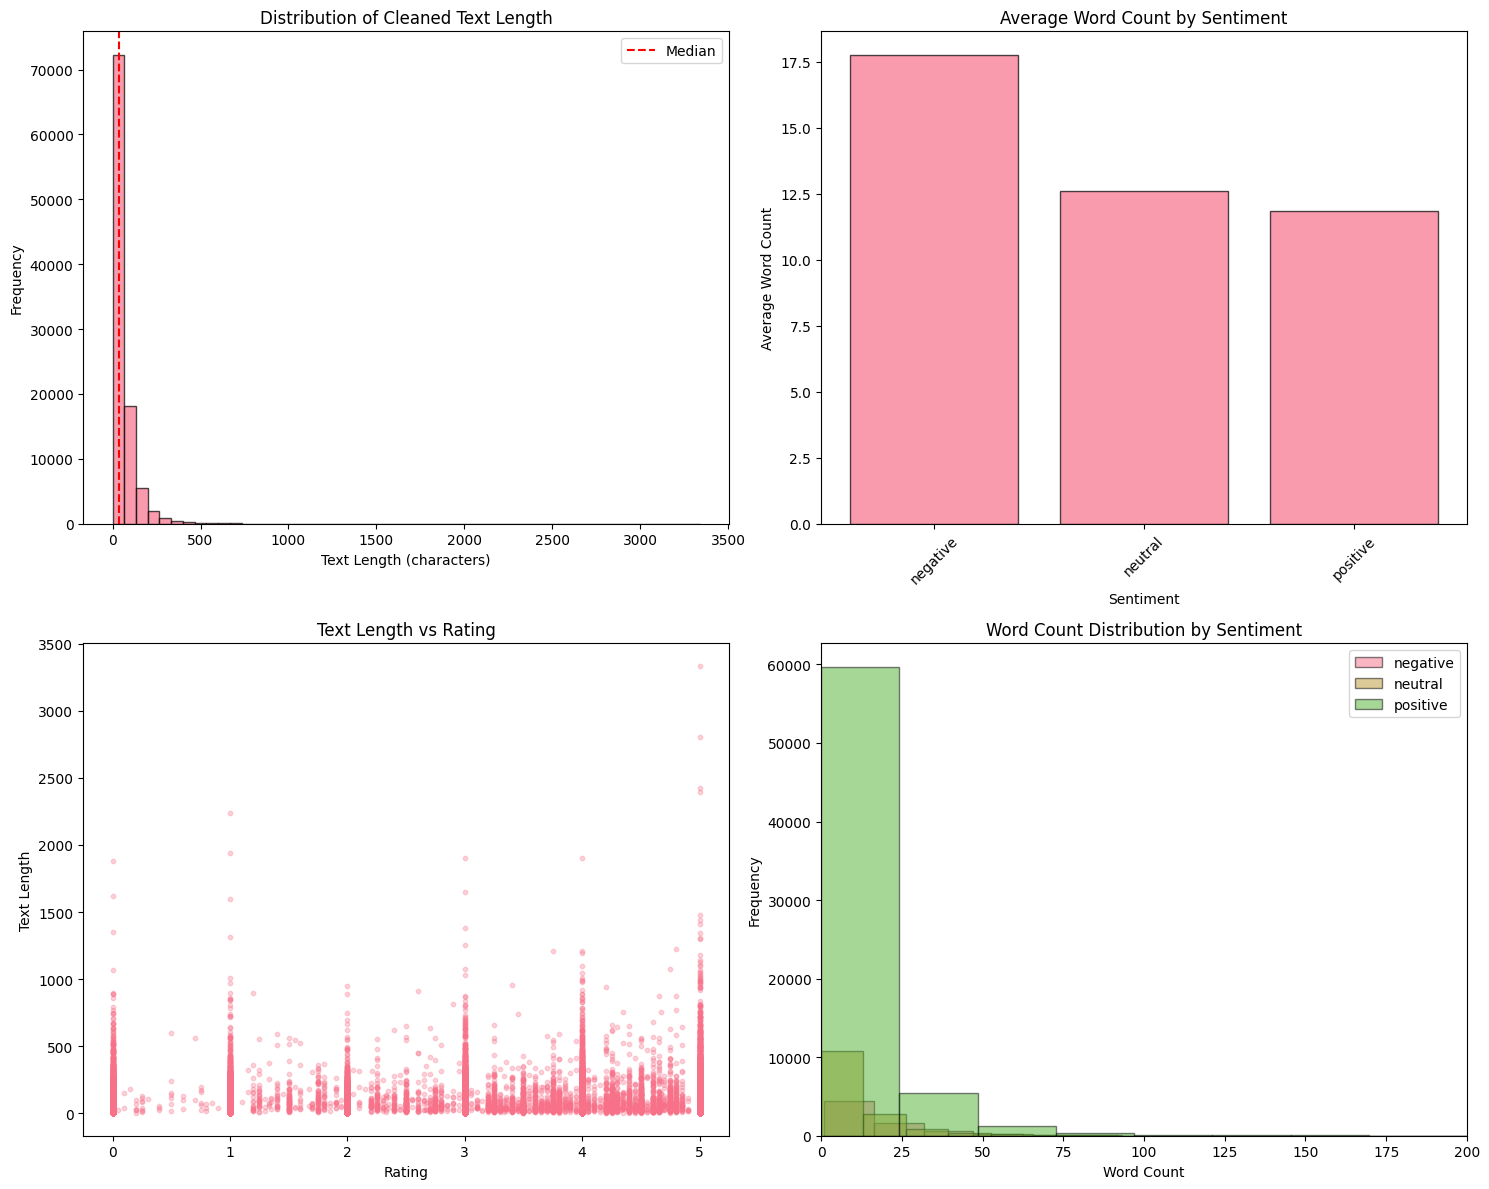

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('default')
sns.set_palette("husl")

# Load data
df = pd.read_csv('../data/processed/preprocessed_data.csv', low_memory=False)

print("="*60)
print("TEXT ANALYSIS - CLEANED DATA")
print("="*60)

# 1. Text Length Distribution After Cleaning
print("\n1. TEXT LENGTH STATISTICS (After Cleaning)")
print("-"*60)
for col in ['full_text_cleaned', 'title_cleaned', 'body_cleaned']:
    if col in df.columns:
        df[f'{col}_length'] = df[col].fillna('').astype(str).apply(len)
        print(f"\n{col}:")
        print(df[f'{col}_length'].describe())

# 2. Word Count Distribution
print("\n2. WORD COUNT DISTRIBUTION")
print("-"*60)
df['cleaned_word_count'] = df['full_text_cleaned'].fillna('').astype(str).apply(lambda x: len(x.split()))
print(df['cleaned_word_count'].describe())

# 3. Most Common Words by Sentiment
print("\n3. TOP 20 WORDS BY SENTIMENT")
print("-"*60)

def get_top_words(texts, n=20):
    all_words = []
    for text in texts:
        if pd.notna(text) and str(text).strip():
            all_words.extend(str(text).split())
    return Counter(all_words).most_common(n)

for sentiment in df['sentiment_label'].unique():
    if pd.notna(sentiment):
        texts = df[df['sentiment_label'] == sentiment]['full_text_cleaned']
        top_words = get_top_words(texts, 20)
        print(f"\n{sentiment.upper()}:")
        for word, count in top_words[:10]:
            print(f"  {word}: {count}")

# 4. Empty Text Analysis
print("\n4. EMPTY TEXT ANALYSIS (After Cleaning)")
print("-"*60)
for col in ['full_text_cleaned', 'title_cleaned', 'body_cleaned']:
    if col in df.columns:
        empty_count = df[col].isna().sum() + (df[col] == '').sum()
        empty_pct = (empty_count / len(df)) * 100
        print(f"{col}: {empty_count} ({empty_pct:.2f}%)")

# 5. Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Text length distribution
axes[0, 0].hist(df['full_text_cleaned_length'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Text Length (characters)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Cleaned Text Length')
axes[0, 0].axvline(df['full_text_cleaned_length'].median(), color='red', linestyle='--', label='Median')
axes[0, 0].legend()

# Plot 2: Word count by sentiment
sentiment_word_counts = df.groupby('sentiment_label')['cleaned_word_count'].mean()
axes[0, 1].bar(sentiment_word_counts.index, sentiment_word_counts.values, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Sentiment')
axes[0, 1].set_ylabel('Average Word Count')
axes[0, 1].set_title('Average Word Count by Sentiment')
axes[0, 1].tick_params(axis='x', rotation=45)

# Plot 3: Text length vs Rating
axes[1, 0].scatter(df['rate'], df['full_text_cleaned_length'], alpha=0.3, s=10)
axes[1, 0].set_xlabel('Rating')
axes[1, 0].set_ylabel('Text Length')
axes[1, 0].set_title('Text Length vs Rating')

# Plot 4: Word count distribution by sentiment
for sentiment in df['sentiment_label'].unique():
    if pd.notna(sentiment):
        data = df[df['sentiment_label'] == sentiment]['cleaned_word_count']
        axes[1, 1].hist(data, bins=30, alpha=0.5, label=sentiment, edgecolor='black')
axes[1, 1].set_xlabel('Word Count')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Word Count Distribution by Sentiment')
axes[1, 1].legend()
axes[1, 1].set_xlim(0, 200)

plt.tight_layout()
plt.savefig('../reports/figures/text_analysis_cleaned.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved: ../reports/figures/text_analysis_cleaned.png")

# 6. Correlation Analysis
print("\n5. CORRELATION: TEXT LENGTH vs ENGAGEMENT")
print("-"*60)
correlation_data = df[['full_text_cleaned_length', 'cleaned_word_count', 'likes', 'dislikes', 'rate']].corr()
print(correlation_data)

print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)


In [3]:
import pandas as pd

# Load and check columns
df = pd.read_csv('../data/processed/preprocessed_data.csv')
print("Available columns:")
print(df.columns.tolist())
print(f"\nTotal columns: {len(df.columns)}")


Available columns:
['id_comment', 'title', 'body', 'created_at', 'rate', 'recommendation_status', 'is_buyer', 'product_id', 'advantages', 'disadvantages', 'likes', 'dislikes', 'seller_title', 'seller_code', 'true_to_size_rate', 'id_product', 'title_fa', 'Rate', 'Rate_cnt', 'Category1', 'Category2', 'Brand', 'Price', 'Seller', 'Is_Fake', 'min_price_last_month', 'sub_category', 'full_text', 'text_length', 'body_length', 'title_length', 'word_count', 'has_advantages', 'has_disadvantages', 'sentiment_label', 'price_change_pct', 'has_product_info', 'product_popularity', 'seller_avg_rate', 'seller_comment_count', 'seller_rate_std', 'seller_total_likes', 'seller_total_dislikes', 'seller_like_ratio', 'full_text_cleaned', 'title_cleaned', 'body_cleaned']

Total columns: 47


C:\Users\ASUS\AppData\Local\Temp\ipykernel_31496\2251713078.py:4: DtypeWarning: Columns (16,19,20,21,23,24,26,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/processed/preprocessed_data.csv')
